In [ ]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import io, stats
import utils.drl as utils
from utils.plots import *
from utils.data import *
from utils.stats_perform import *
from utils.model_fitting import *
from utils.path import PathConfig,FigureWithData
import warnings
warnings.filterwarnings("ignore")
from numpy.polynomial.polynomial import Polynomial

from random import sample
from scipy import stats

seed_value =1234
np.random.seed(seed_value)
random.seed(seed_value)


fig_dir = os.path.join('figures', 'figure_S3_4')
data_fig_dir = os.path.join('data', 'source_data', 'figure_S3_4')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)


## Habenula lesion data analysis

This notebook performs the  analysis of the Habenula lesion dataset performed in the manuscript:  *Romero Pinto, S., & Uchida, N. (2023). **Tonic dopamine and biases in value learning linked through a biologically inspired reinforcement learning model***

The dataset consists of electrophysiological recordgins of VTA dopamine neurons and the behavioral readouts  published originally in *Habenula Lesions Reveal that Multiple Mechanisms Underlie Dopamine Prediction Errors. Neuron, 87(6), 1304–1316 [https://doi.org/10.1016/j.neuron.2015.08.028*]

**Note:** To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [3]:
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir
col_g = ['black','red']
groups = ['control','lesion']
nf = [45,44]
probs_cues = [10,50,90]
s = dict()
s['baselineWindow']      = [-1500, -500]  #% in units of milliseconds
s['psthWindow']          = [-1500, 4500]  #% in units of milliseconds
s['cueWindow']           = [0, 400]   # in units of milliseconds
s['traceWindow']         = [500, 2000]  #% in units of milliseconds
s['outcomeWindow']       = [2000, 2600] # % in units of milliseconds
s['outcomeWindowLate']       = [2200, 2600]  #% in units of milliseconds
s['outcomeWindowFreeLate']   = [200, 400]  #% in units of milliseconds
s['psthResolution']          = 2   #% in units of milliseconds
s['normalizeTo50']           = True # % when true, this will normalize the 50% responses for each cell according to the mean (across cells) of 50% responses in that animal.
s['smoothingTimeConst']      = 20;  #% 20 is what the eshel paper used (units of milliseconds)
s['interestingTrialTypes']   = np.arange(15)
s['maxTrialsPerType'] = 300
s['indeces'] = dict()
s['indeces']['puff80'] = [6,7]
s['indeces']['prob10']= [4,5]
s['indeces']['prob50'] = [2,3]
s['indeces']['prob90']= [0,1]
s['indeces']['freeRew'] = 8
s['indeces']['freePuff'] = 9
alpha_p = .05

loader_c = DataLoad(s)
data_path = os.path.join(g_dir, 'raw_data',groups[0])
data_path
file_list = glob.glob(data_path + '/*.pickle')
PSTH, PSTC, spikeRaster = loader_c.load_cells(file_list,response_type = 'spikes')
print('computing responses for '+ groups[0])
loader_c.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_c.load_cells(file_list,response_type = 'licks')
_,_,_ =loader_c.compute_lick_responses(PSTH_licks)
loader_c.get_cells_same_day(file_list)

loader_l= DataLoad(s)
data_path = os.path.join(g_dir,'raw_data', groups[1])
file_list = glob.glob(data_path + '/*.pickle')
PSTH, PSTC, spikeRaster = loader_l.load_cells(file_list,response_type = 'spikes')
loader_l.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_l.load_cells(file_list,response_type = 'licks')
_,_,_=loader_l.compute_lick_responses(PSTH_licks)
loader_l.get_cells_same_day(file_list)

Cell Number: 100%|██████████| 45/45 [00:12<00:00,  3.59it/s]


computing responses for control


Cell Number: 100%|██████████| 44/44 [00:05<00:00,  7.44it/s]


### Supp Figure a
- Compute  utility axis based on mean responses across neurons


Saved figure to figures/figure_S3_4/figure_S3a.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3a.txt


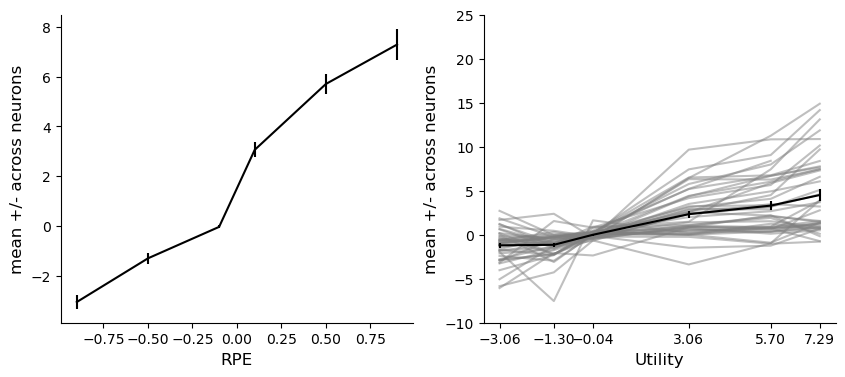

In [31]:
#%% Compute taus from firing rates:
rpes_x = [-.9,-.5,-.1,.1,.5,.9]
indeces_resp = [loader_l.indeces_prob90[1],loader_l.indeces_prob50[1],loader_l.indeces_prob10[1],
                loader_l.indeces_prob90[0],loader_l.indeces_prob50[0],loader_l.indeces_prob10[0],]
# Format FR to: (n_cells,n_types,n_trials) 
per_cell_l = np.asarray([loader_l.outcomeResponses[:,ii,:] for ii in indeces_resp])
per_cell_c = np.asarray([loader_c.outcomeResponses[:,ii,:] for ii in indeces_resp])

#% =% Compute taus and zerocrossing poitns
method_zcross='count'
groups_resp = [per_cell_c,per_cell_l]
taus_v,id_disc,zcross_v,zcross_rpev,apos,aneg ,utility_axis_v,critvals_v= [],[],[],[],[],[],[],[]
for iresp in groups_resp:
    per_cell = iresp.copy().transpose(1,0,2)
    utility_axis = np.floor(np.nanmean(np.nanmean(per_cell,axis=2),axis=0)*1000)/1000
    utility_axis_std = np.floor(np.nanstd(np.nanmean(per_cell,axis=2),axis=0)*1000)/1000/np.sqrt(per_cell.shape[0])
    m = [utils.compute_drl_metrics(per_cell[i_cell,:,:],utility_axis,method_zcross) for i_cell in range(per_cell.shape[0])]
    taus_,alpha_pos,alpha_neg,zcross_util,zcross_rpe,i_disc = utils.extract_metrics(m,[utility_axis for _ in range(len(m))],rpes_x)
    taus_v.append(taus_)
    zcross_v.append(zcross_util)
    critvals_v.append([im[-1][-1] for im in m])
    utility_axis_v.append([utility_axis,utility_axis_std])
    apos.append(alpha_pos)
    aneg.append(alpha_neg)
    zcross_rpev.append(zcross_rpe)
    id_disc.append(i_disc)


# Plot for control
fig,ax = plt.subplots(1,2,figsize=(10,4))
ax[0].errorbar(rpes_x,utility_axis_v[0][0],utility_axis_v[0][1],color='black')
plot_config(ax[0],'RPE','mean +/- across neurons',12,False)

_=[ax[1].plot(utility_axis_v[0][0],np.nanmean(per_cell[icell,:,:],axis=1),color='grey',alpha=.5) for icell in range(per_cell.shape[0])]
ax[1].errorbar(utility_axis_v[0][0],np.nanmean(np.nanmean(per_cell,axis=2),axis=0),
               np.nanstd(np.nanmean(per_cell,axis=2),axis=0)/np.sqrt(per_cell.shape[0]), color='black')
ax[1].set_ylim([-10,25])
plot_config(ax[1],'Utility','mean +/- across neurons',12,False)
_=ax[1].set_xticks(utility_axis_v[0][0])


# 1. Create wrapper
fig_data_utility_control = FigureWithData(fig)

# 2. Save utility axis values
utility_axis = utility_axis_v[0][0]
utility_axis_sem = utility_axis_v[0][1]

utility_axis_data = np.column_stack((rpes_x, utility_axis, utility_axis_sem))
fig_data_utility_control.add_data(
    "Utility axis values (Control group)",
    utility_axis_data,
    ['RPE_bin', 'Utility_mean', 'Utility_SEM']
)

# 3. Save single-cell firing rates
# (utility_axis x firing rate curves per cell)
n_cells = per_cell.shape[0]
fr_single_cells = np.full((len(utility_axis), n_cells), np.nan)

for icell in range(n_cells):
    fr_single_cells[:, icell] = np.nanmean(per_cell[icell, :, :], axis=1)

fr_single_data = np.column_stack((utility_axis, fr_single_cells))
headers_single = ['Utility_axis'] + [f'Cell_{i}' for i in range(n_cells)]

fig_data_utility_control.add_data(
    "Single-cell mean firing rates (Control group)",
    fr_single_data,
    headers_single
)

# 4. Save population mean ± SEM firing rates
pop_mean = np.nanmean(fr_single_cells, axis=1)
pop_sem = np.nanstd(fr_single_cells, axis=1) / np.sqrt(n_cells)
pop_data = np.column_stack((utility_axis, pop_mean, pop_sem))
fig_data_utility_control.add_data(
    "Population mean firing rates (Control group)",
    pop_data,
    ['Utility_axis', 'Pop_FR_mean', 'Pop_FR_SEM']
)

# 5. Save everything
fig_data_utility_control.save(
    base_filename='figure_S3a',
    folder_data= data_fig_dir,
    folder_figures=fig_dir
)


Saved figure to figures/figure_S3_4/figure_S3b_neuron_2.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3b_neuron_2.txt
Saved figure to figures/figure_S3_4/figure_S3b_neuron_3.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3b_neuron_3.txt
Saved figure to figures/figure_S3_4/figure_S3b_neuron_6.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3b_neuron_6.txt
Saved figure to figures/figure_S3_4/figure_S3b_neuron_8.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3b_neuron_8.txt
Saved figure to figures/figure_S3_4/figure_S3b_neuron_21.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3b_neuron_21.txt
Saved figure to figures/figure_S3_4/figure_S3b_neuron_22.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3b_neuron_22.txt
Saved figure to figures/figure_S3_4/figure_S3b_neuron_31.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S3b_neuron_31.txt
Saved figure to figures/figure_S3_4

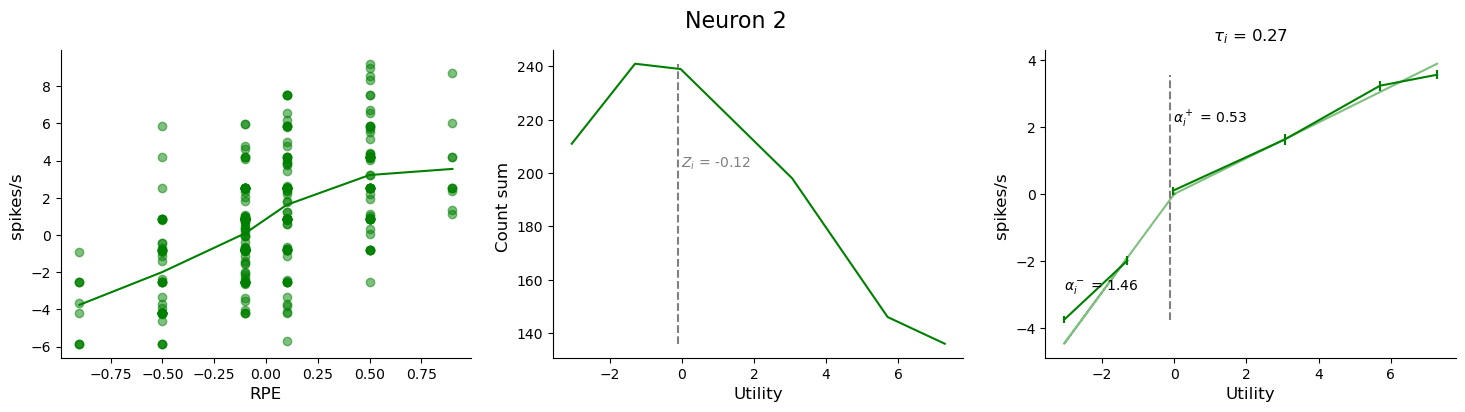

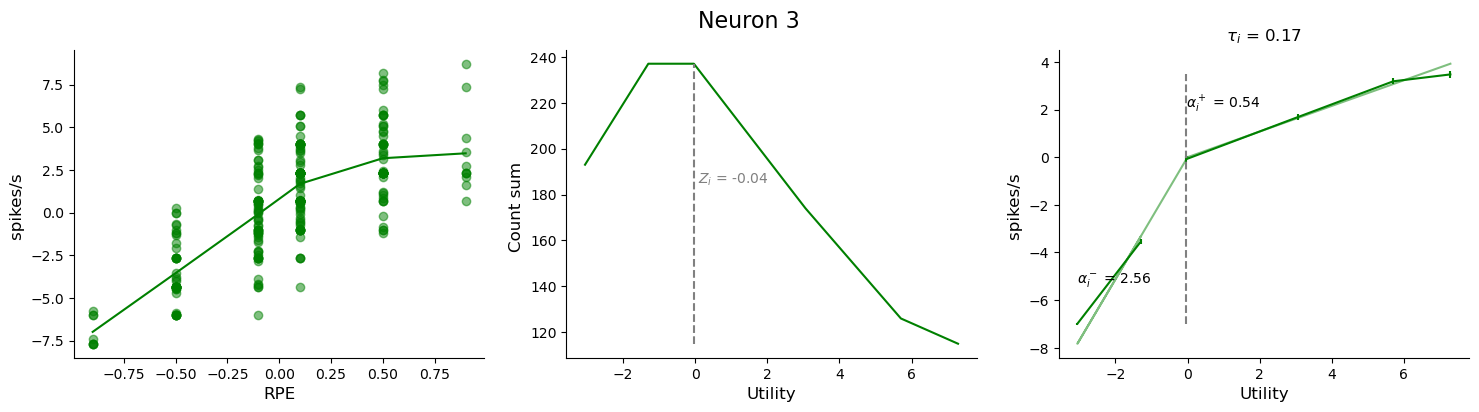

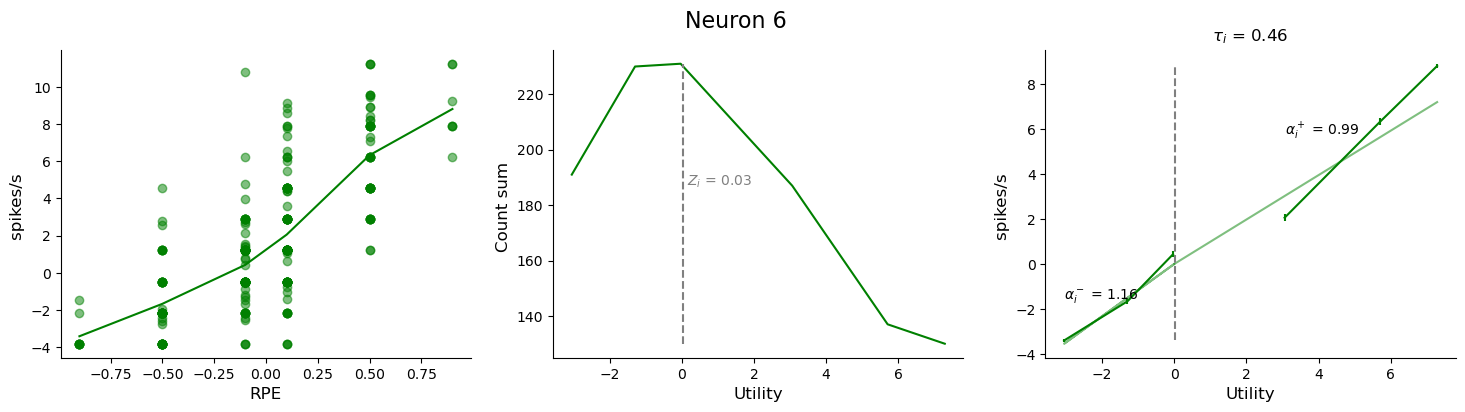

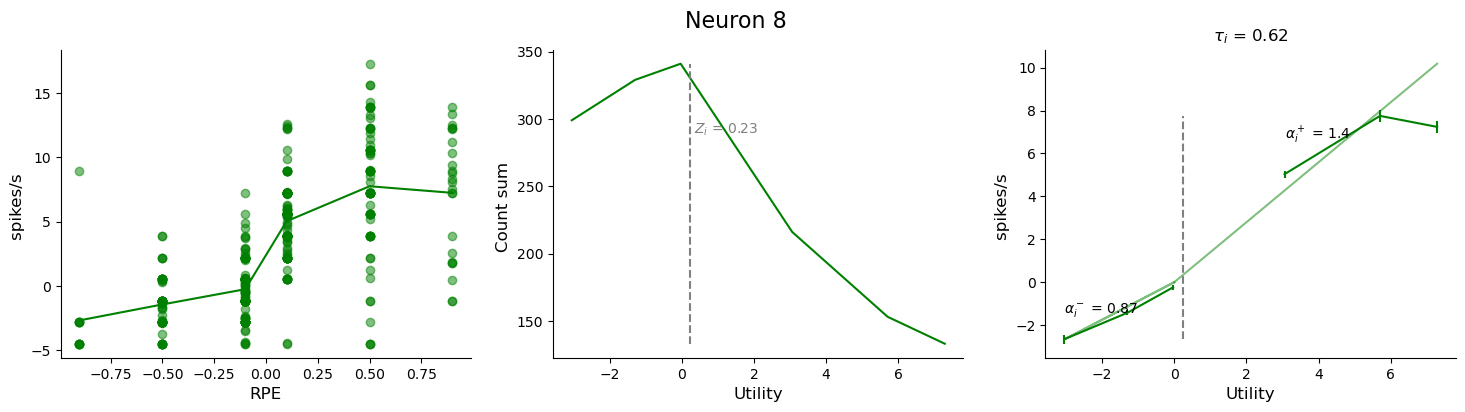

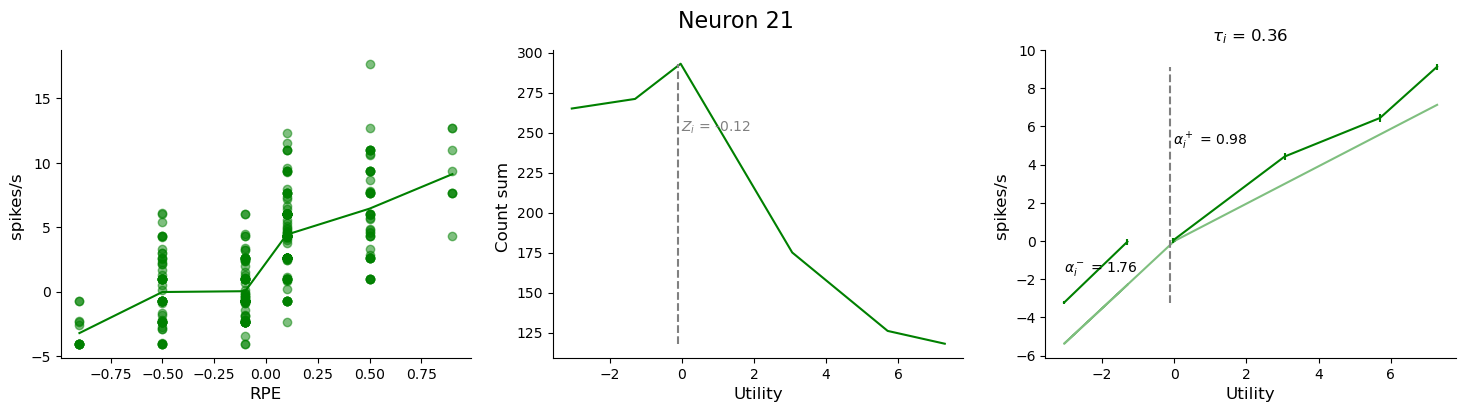

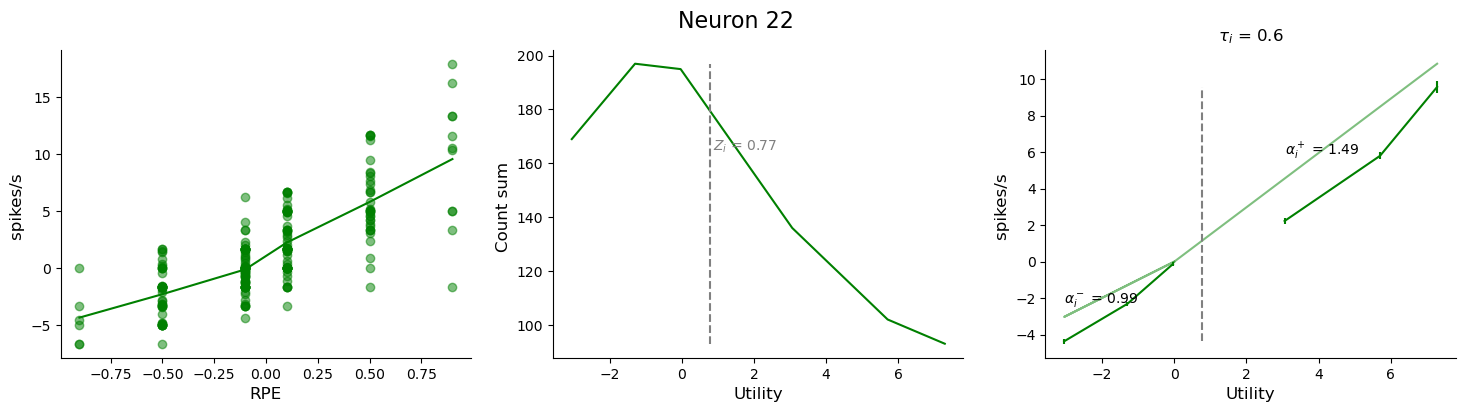

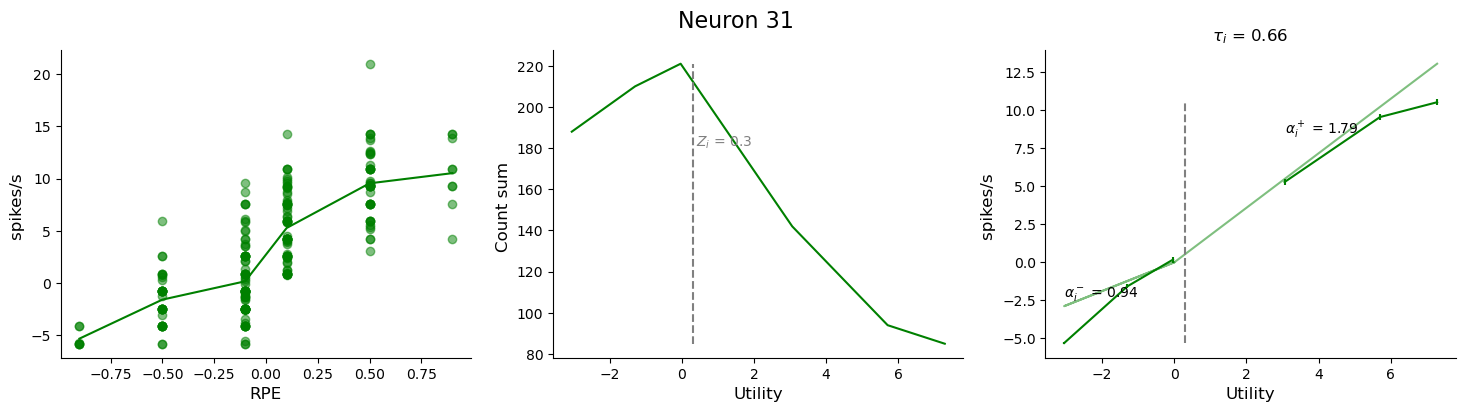

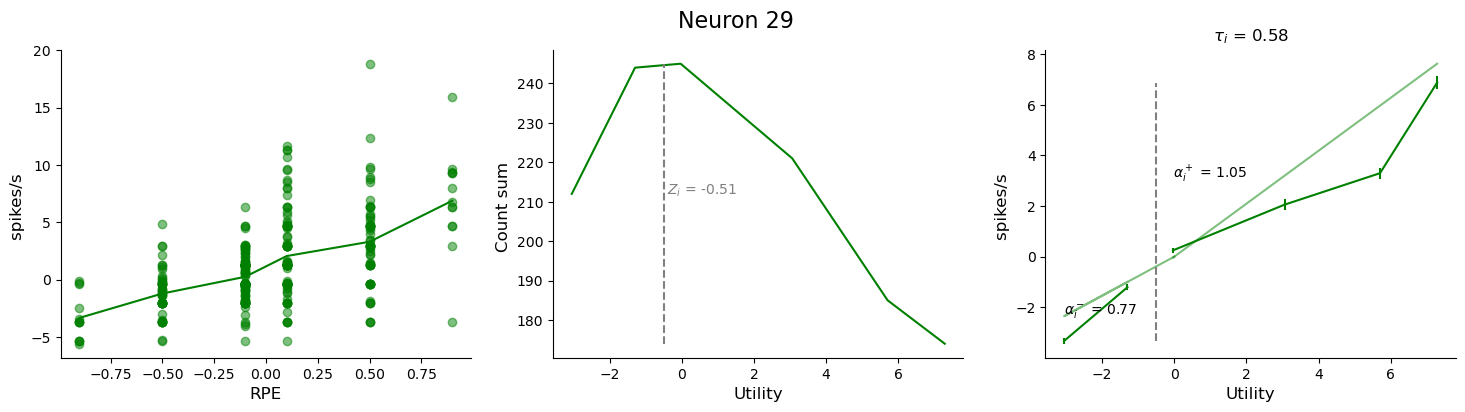

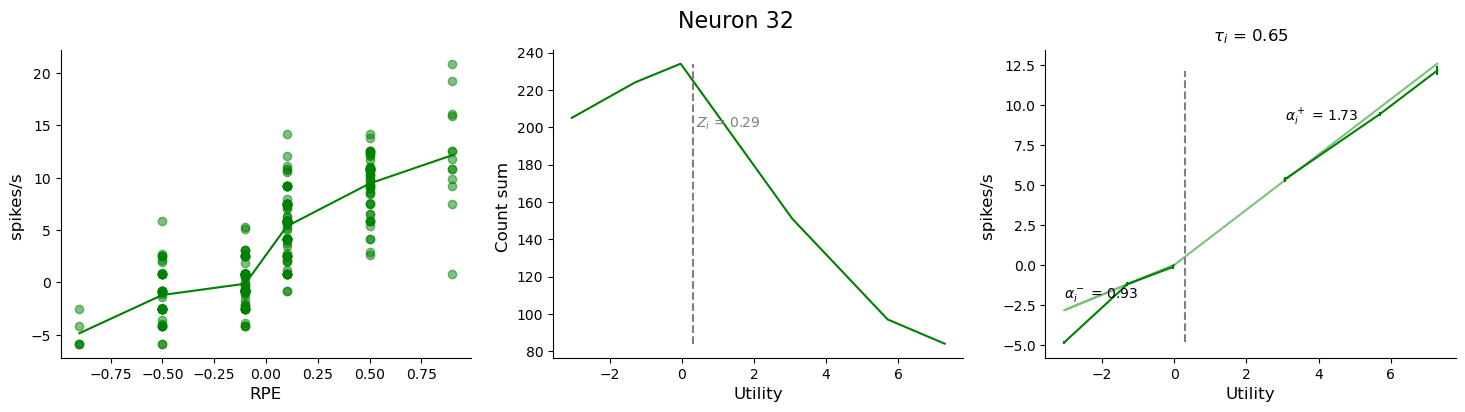

In [35]:
ineurons=[1,2,5,7,20,21,30,28,31]
# ineurons=np.arange(44)
#1,2,5,7
color_cell = 'green'
id_group = 0
for ineuron in ineurons:
    utility_axis = utility_axis_v[id_group][0]
    per_cell_i = per_cell_c[:,ineuron,:]
    count_vals_i = critvals_v[id_group][ineuron]
    tau_i = taus_v[id_group][ineuron]
    zcross_i = zcross_v[id_group][ineuron]
    apos_i = apos[id_group][ineuron]
    aneg_i = aneg[id_group][ineuron]
    idneg = np.argwhere(utility_axis<=zcross_i).flatten()
    idpos = np.argwhere(utility_axis>=zcross_i).flatten()
    resp_mean = np.nanmean(per_cell_i,axis=1)
    resp_sem = np.nanstd(per_cell_i,axis=1)/np.sqrt(per_cell_i.shape[1])

    fig,ax = plt.subplots(1,3,figsize=(18,4))
    ax[0].plot(rpes_x,resp_mean,color=color_cell)
    [ax[0].plot(rpes_x[ics],per_cell_i[ics,:][None,:],'o',color=color_cell,alpha=.5) for ics in range(per_cell_i.shape[0])]
    plot_config(ax[0],'RPE','spikes/s ',12,False)

    ax[1].plot(utility_axis,count_vals_i[1:],color=color_cell)
    ax[1].plot([zcross_i,zcross_i],[np.min(count_vals_i),np.max(count_vals_i)],'--',color='grey')
    ax[1].text(zcross_i+0.1,np.nanmedian(count_vals_i),r'$Z_i$ = '+str(np.round(zcross_i,2)),color='grey')
    plot_config(ax[1],'Utility','Count sum ',12,False)
    ax[2].errorbar(utility_axis[idpos],resp_mean[idpos],resp_sem[idpos] ,color=color_cell)
    ax[2].plot(np.concatenate([[0],utility_axis[idpos]]),np.concatenate([[0],utility_axis[idpos]])*apos_i,color=color_cell,alpha=.5)
    ax[2].errorbar(utility_axis[idneg],resp_mean[idneg],resp_sem[idneg] ,color=color_cell)
    ax[2].plot(np.concatenate([[0],utility_axis[idneg]]),np.concatenate([[0],utility_axis[idneg]])*aneg_i,color=color_cell,alpha=.5)
    ax[2].plot([zcross_i,zcross_i],[np.min(resp_mean),np.max(resp_mean)],'--',color='grey')
    ax[2].set_title(r'$\tau_i$ = '+str(np.round(tau_i,2)))
    ax[2].text(np.min(utility_axis[idpos]),np.mean(resp_mean[idpos]),r'$\alpha_i^+$ = '+str(np.round(apos_i,2)),color='black')
    ax[2].text(np.min(utility_axis[idneg]),np.mean(resp_mean[idneg]),r'$\alpha_i^-$ = '+str(np.round(aneg_i,2)),color='black')
    plot_config(ax[2],'Utility','spikes/s ',12,False)
    plt.suptitle('Neuron '+str(ineuron+1),fontsize=16)

    # 2. Wrap with FigureWithData
    fig_data_neuron = FigureWithData(fig)

    # Save RPE → spike rate
    rpe_curve = np.column_stack((rpes_x, resp_mean))
    fig_data_neuron.add_data(
        "RPE vs Spike Rate",
        rpe_curve,
        ['RPE_bin', 'SpikeRate_mean']
    )

    # Save Utility → count values
    count_curve = np.column_stack((utility_axis, count_vals_i[1:]))
    fig_data_neuron.add_data(
        "Utility vs Count Sum",
        count_curve,
        ['Utility', 'Count_Sum']
    )

    # Save Utility → spike rate (positive/negative sides)
    fit_curve_pos = np.column_stack((utility_axis[idpos], resp_mean[idpos]))
    fit_curve_neg = np.column_stack((utility_axis[idneg], resp_mean[idneg]))
    fig_data_neuron.add_data(
        "Spike Rate vs Utility (positive side)",
        fit_curve_pos,
        ['Utility_pos', 'SpikeRate_pos']
    )
    fig_data_neuron.add_data(
        "Spike Rate vs Utility (negative side)",
        fit_curve_neg,
        ['Utility_neg', 'SpikeRate_neg']
    )

    # Save fit parameters
    param_array = np.array([[tau_i, apos_i, aneg_i, zcross_i]])
    param_headers = [r'tau_i', r'alpha_pos', r'alpha_neg', r'zcross']
    fig_data_neuron.add_stats(
        "Fit Parameters",
        param_array,
        param_headers
    )

    # # 3. Save figure + data
    fig_data_neuron.save(
        base_filename=f'figure_S3b_neuron_{ineuron+1}',
        folder_data= data_fig_dir,
        folder_figures= fig_dir
    )

100%|██████████| 20/20 [00:00<00:00, 23.00it/s]


Saved figure to figures/figure_S3_4/figure_S4_bootstrap_taus_zcross.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S4_bootstrap_taus_zcross.txt


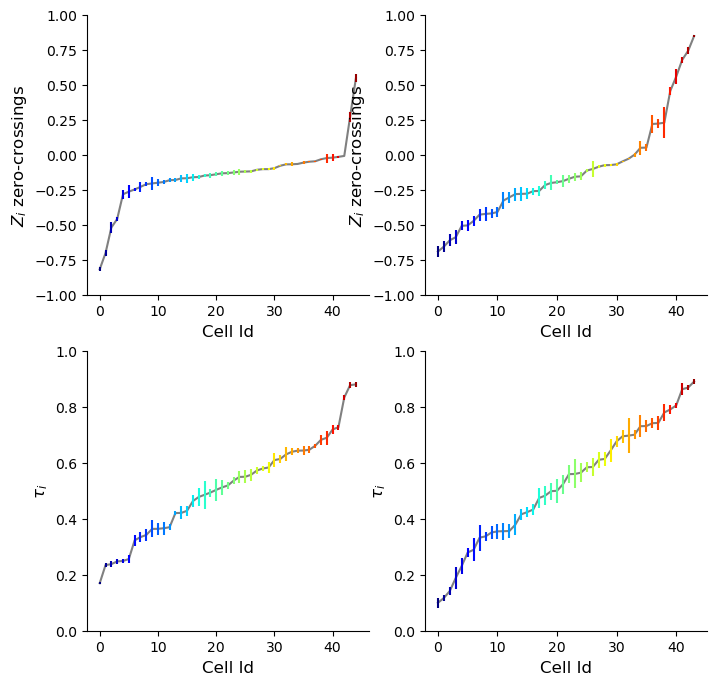

In [37]:
# Compute tau/zscorss across partitions
np.random.seed(seed_value)
method_zcross='mult'
n_samples = 50
n_iterations = 20
taus_iterations, zcross_iterations = [],[]
for iresp in groups_resp:
    taus_v,zcross_v,zcross_rpev,apos,aneg = [],[],[],[],[]

    per_cell = iresp.copy().transpose(1,0,2)
    ntrials_include = np.max([np.argwhere(ii==0).flatten()[0] for ii in np.nansum(per_cell[:,:,:],axis=1)])
    per_cell = per_cell[:,:,:ntrials_include]

    for iter in tqdm(range(n_iterations)):
        id_trials_samp = np.random.choice(np.arange(per_cell.shape[2]),n_samples,replace=True)
        per_cell_part = per_cell[:,:,id_trials_samp]
        utility_axis = np.floor(np.nanmean(np.nanmean(per_cell_part,axis=2),axis=0)*1000)/1000
        utility_axis_std = np.floor(np.nanstd(np.nanmean(per_cell_part,axis=2),axis=0)*1000)/1000/np.sqrt(per_cell_part.shape[0])
        m = [utils.compute_drl_metrics(per_cell_part[i_cell,:,:],utility_axis,method_zcross) for i_cell in range(per_cell_part.shape[0])]
        taus_,alpha_pos,alpha_neg,zcross_util,zcross_rpe,i_disc = utils.extract_metrics(m,[utility_axis for _ in range(len(m))],rpes_x,discard_nan=False)
        taus_v.append(taus_)
        zcross_v.append(zcross_util)
        apos.append(alpha_pos)
        aneg.append(alpha_neg)
        zcross_rpev.append(zcross_rpe)
    zcross_iterations.append(zcross_rpev)
    taus_iterations.append(taus_v)

fig,ax = plt.subplots(2,2,figsize=(8,8))
fig_data_bootstrap = FigureWithData(fig)


for ig in range(2):
    taus_v = np.asarray(taus_iterations[ig])
    zcross_v =  np.asarray(zcross_iterations[ig])
    idsort_taus = np.argsort(np.nanmean(taus_v,axis=0))
    idsort_zcross = np.argsort(np.nanmean(zcross_v,axis=0))
    cells_id = np.arange(taus_v.shape[1])
    mu_tau_sorted= np.nanmean(taus_v,axis=0)[idsort_taus]
    sem_tau_sorted= np.nanstd(taus_v,axis=0)[idsort_taus]/np.sqrt(len(cells_id))

    mu_zcross_sorted= np.nanmean(zcross_v,axis=0)[idsort_zcross]
    sem_zcross_sorted= np.nanstd(zcross_v,axis=0)[idsort_zcross]/np.sqrt(len(cells_id))
    
    ax[0,ig].plot(cells_id,mu_zcross_sorted,color='grey')
    _= [ax[0,ig].errorbar(cells_id[ii],mu_zcross_sorted[ii],sem_zcross_sorted[ii],color=cm.jet(ii/len(cells_id))) for ii in np.arange(len(cells_id))]
    plot_config(ax[0,ig],'Cell Id',r'$Z_i$ zero-crossings ',12,False)
    ax[1,ig].plot(cells_id,mu_tau_sorted,color='grey')
    _= [ax[1,ig].errorbar(cells_id[ii],mu_tau_sorted[ii],sem_tau_sorted[ii],color=cm.jet(ii/len(cells_id))) for ii in np.arange(len(cells_id))]
    plot_config(ax[1,ig],'Cell Id',r'$\tau_i$',12,False)
    ax[0,ig].set_ylim([-1,1])
    ax[1,ig].set_ylim([0,1])

    # Save sorted taus
    tau_sorted_data = np.column_stack((cells_id, mu_tau_sorted, sem_tau_sorted))
    fig_data_bootstrap.add_data(
        f"Taus_sorted_group{ig}",
        tau_sorted_data,
        ['Cell_ID', 'Tau_mean', 'Tau_SEM']
    )

    # Save sorted zero-crossings
    zcross_sorted_data = np.column_stack((cells_id, mu_zcross_sorted, sem_zcross_sorted))
    fig_data_bootstrap.add_data(
        f"Zcross_sorted_group{ig}",
        zcross_sorted_data,
        ['Cell_ID', 'Zcross_mean', 'Zcross_SEM']
    )

    # Save full bootstrapped taus per cell
    taus_full_data = np.column_stack((np.arange(taus_v.shape[0])[:, None], taus_v))
    taus_headers = ['Iteration'] + [f'Cell_{c}' for c in range(taus_v.shape[1])]
    fig_data_bootstrap.add_data(
        f"Taus_bootstrap_full_group{ig}",
        taus_full_data,
        taus_headers
    )

    # Save full bootstrapped zcross per cell
    zcross_full_data = np.column_stack((np.arange(zcross_v.shape[0])[:, None], zcross_v))
    zcross_headers = ['Iteration'] + [f'Cell_{c}' for c in range(zcross_v.shape[1])]
    fig_data_bootstrap.add_data(
        f"Zcross_bootstrap_full_group{ig}",
        zcross_full_data,
        zcross_headers
    )


# 2. Save all data and figure
fig_data_bootstrap.save(
    base_filename='figure_S4_bootstrap_taus_zcross',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)

In [15]:
# Compute tau vs zscorss correlations across partitions
n_iterations = 1000
method_zcross='count'
taus_half1_g,taus_half2_g, zcross_half1_g,zcross_half2_g = [],[],[],[]
correlation_taus_taus_g, correlation_zcross_taus_g, correlation_zcross_zcross_g=[],[],[]
correlation_taus_taus_shuff_g, correlation_zcross_taus_shuff_g, correlation_zcross_zcross_shuff_g=[],[],[]
for iresp in groups_resp:
    taus_half1,taus_half2, zcross_half1,zcross_half2 = [],[],[],[]

    per_cell = iresp.copy().transpose(1,0,2)
    correlation_zcross_taus,correlation_taus_taus,correlation_zcross_zcross = [],[],[]
    correlation_zcross_taus_shuff, correlation_taus_taus_shuff , correlation_zcross_zcross_shuff= [],[],[]
    for iter in tqdm(range(n_iterations)):
        id_trials_shuffle = np.random.permutation(np.arange(per_cell.shape[2]))
        id_trials_half1,id_trials_half2 = np.array_split(id_trials_shuffle, 2, axis=0)

        per_cell_half1 = per_cell[:,:,id_trials_half1]
        per_cell_half2 = per_cell[:,:,id_trials_half2]

        utility_axis1 = np.floor(np.nanmean(np.nanmean(per_cell_half1,axis=2),axis=0)*1000)/1000
        utility_axis2 = np.floor(np.nanmean(np.nanmean(per_cell_half2,axis=2),axis=0)*1000)/1000

        m1 = [utils.compute_drl_metrics(per_cell_half1[i_cell,:,:],utility_axis1,method_zcross) for i_cell in range(per_cell_half1.shape[0])]
        m2 = [utils.compute_drl_metrics(per_cell_half2[i_cell,:,:],utility_axis2,method_zcross) for i_cell in range(per_cell_half2.shape[0])]

        taus_1,_,_,zcross_util1,zcross_rpe1,_ = utils.extract_metrics(m1,[utility_axis1 for _ in range(len(m1))],rpes_x,discard_nan=False)
        taus_2,_,_,zcross_util2,zcross_rpe2,_ = utils.extract_metrics(m2,[utility_axis2 for _ in range(len(m2))],rpes_x,discard_nan=False)
        taus_1_shuff = np.random.permutation(taus_1)
        taus_2_shuff = np.random.permutation(taus_2)
        zcross_util1_shuff = np.random.permutation(zcross_rpe1)
        zcross_util2_shuff = np.random.permutation(zcross_rpe2)
        r_zt,_ = nanpearsonr(taus_1,zcross_rpe1)
        r_tt,_ = nanpearsonr(taus_1,taus_2)
        r_zz,_ = nanpearsonr(zcross_rpe1,zcross_rpe2)

        r_zt_shuff,_ = nanpearsonr(taus_1_shuff,zcross_util2_shuff)
        r_tt_shuff,_ = nanpearsonr(taus_1_shuff,taus_2_shuff)
        r_zz_shuff,_ = nanpearsonr(zcross_util1_shuff,zcross_util2_shuff)

        correlation_zcross_taus.append(r_zt)
        correlation_taus_taus.append(r_tt)
        correlation_zcross_zcross.append(r_zz)

        correlation_zcross_taus_shuff.append(r_zt_shuff)
        correlation_taus_taus_shuff.append(r_tt_shuff)
        correlation_zcross_zcross_shuff.append(r_zz_shuff)
        taus_half1.append(taus_1)
        taus_half2.append(taus_2)
        zcross_half1.append(zcross_rpe1)
        zcross_half2.append(zcross_rpe2)

    taus_half1_g.append(taus_half1)
    taus_half2_g.append(taus_half2)
    zcross_half1_g.append(zcross_half1)
    zcross_half2_g.append(zcross_half2)
    correlation_taus_taus_g.append(correlation_taus_taus)
    correlation_zcross_taus_g.append(correlation_zcross_taus)
    correlation_zcross_zcross_g.append(correlation_zcross_zcross)
    correlation_taus_taus_shuff_g.append(correlation_taus_taus_shuff)
    correlation_zcross_taus_shuff_g.append(correlation_zcross_taus_shuff)
    correlation_zcross_zcross_shuff_g.append(correlation_zcross_zcross_shuff)

100%|██████████| 1000/1000 [01:42<00:00,  9.72it/s]


Saved figure to figures/figure_S3_4/figure_S4_scatter_correlation_analysis.pdf
Saved data and stats to data/figure_data/figure_S3_4/figure_S4_scatter_correlation_analysis.txt


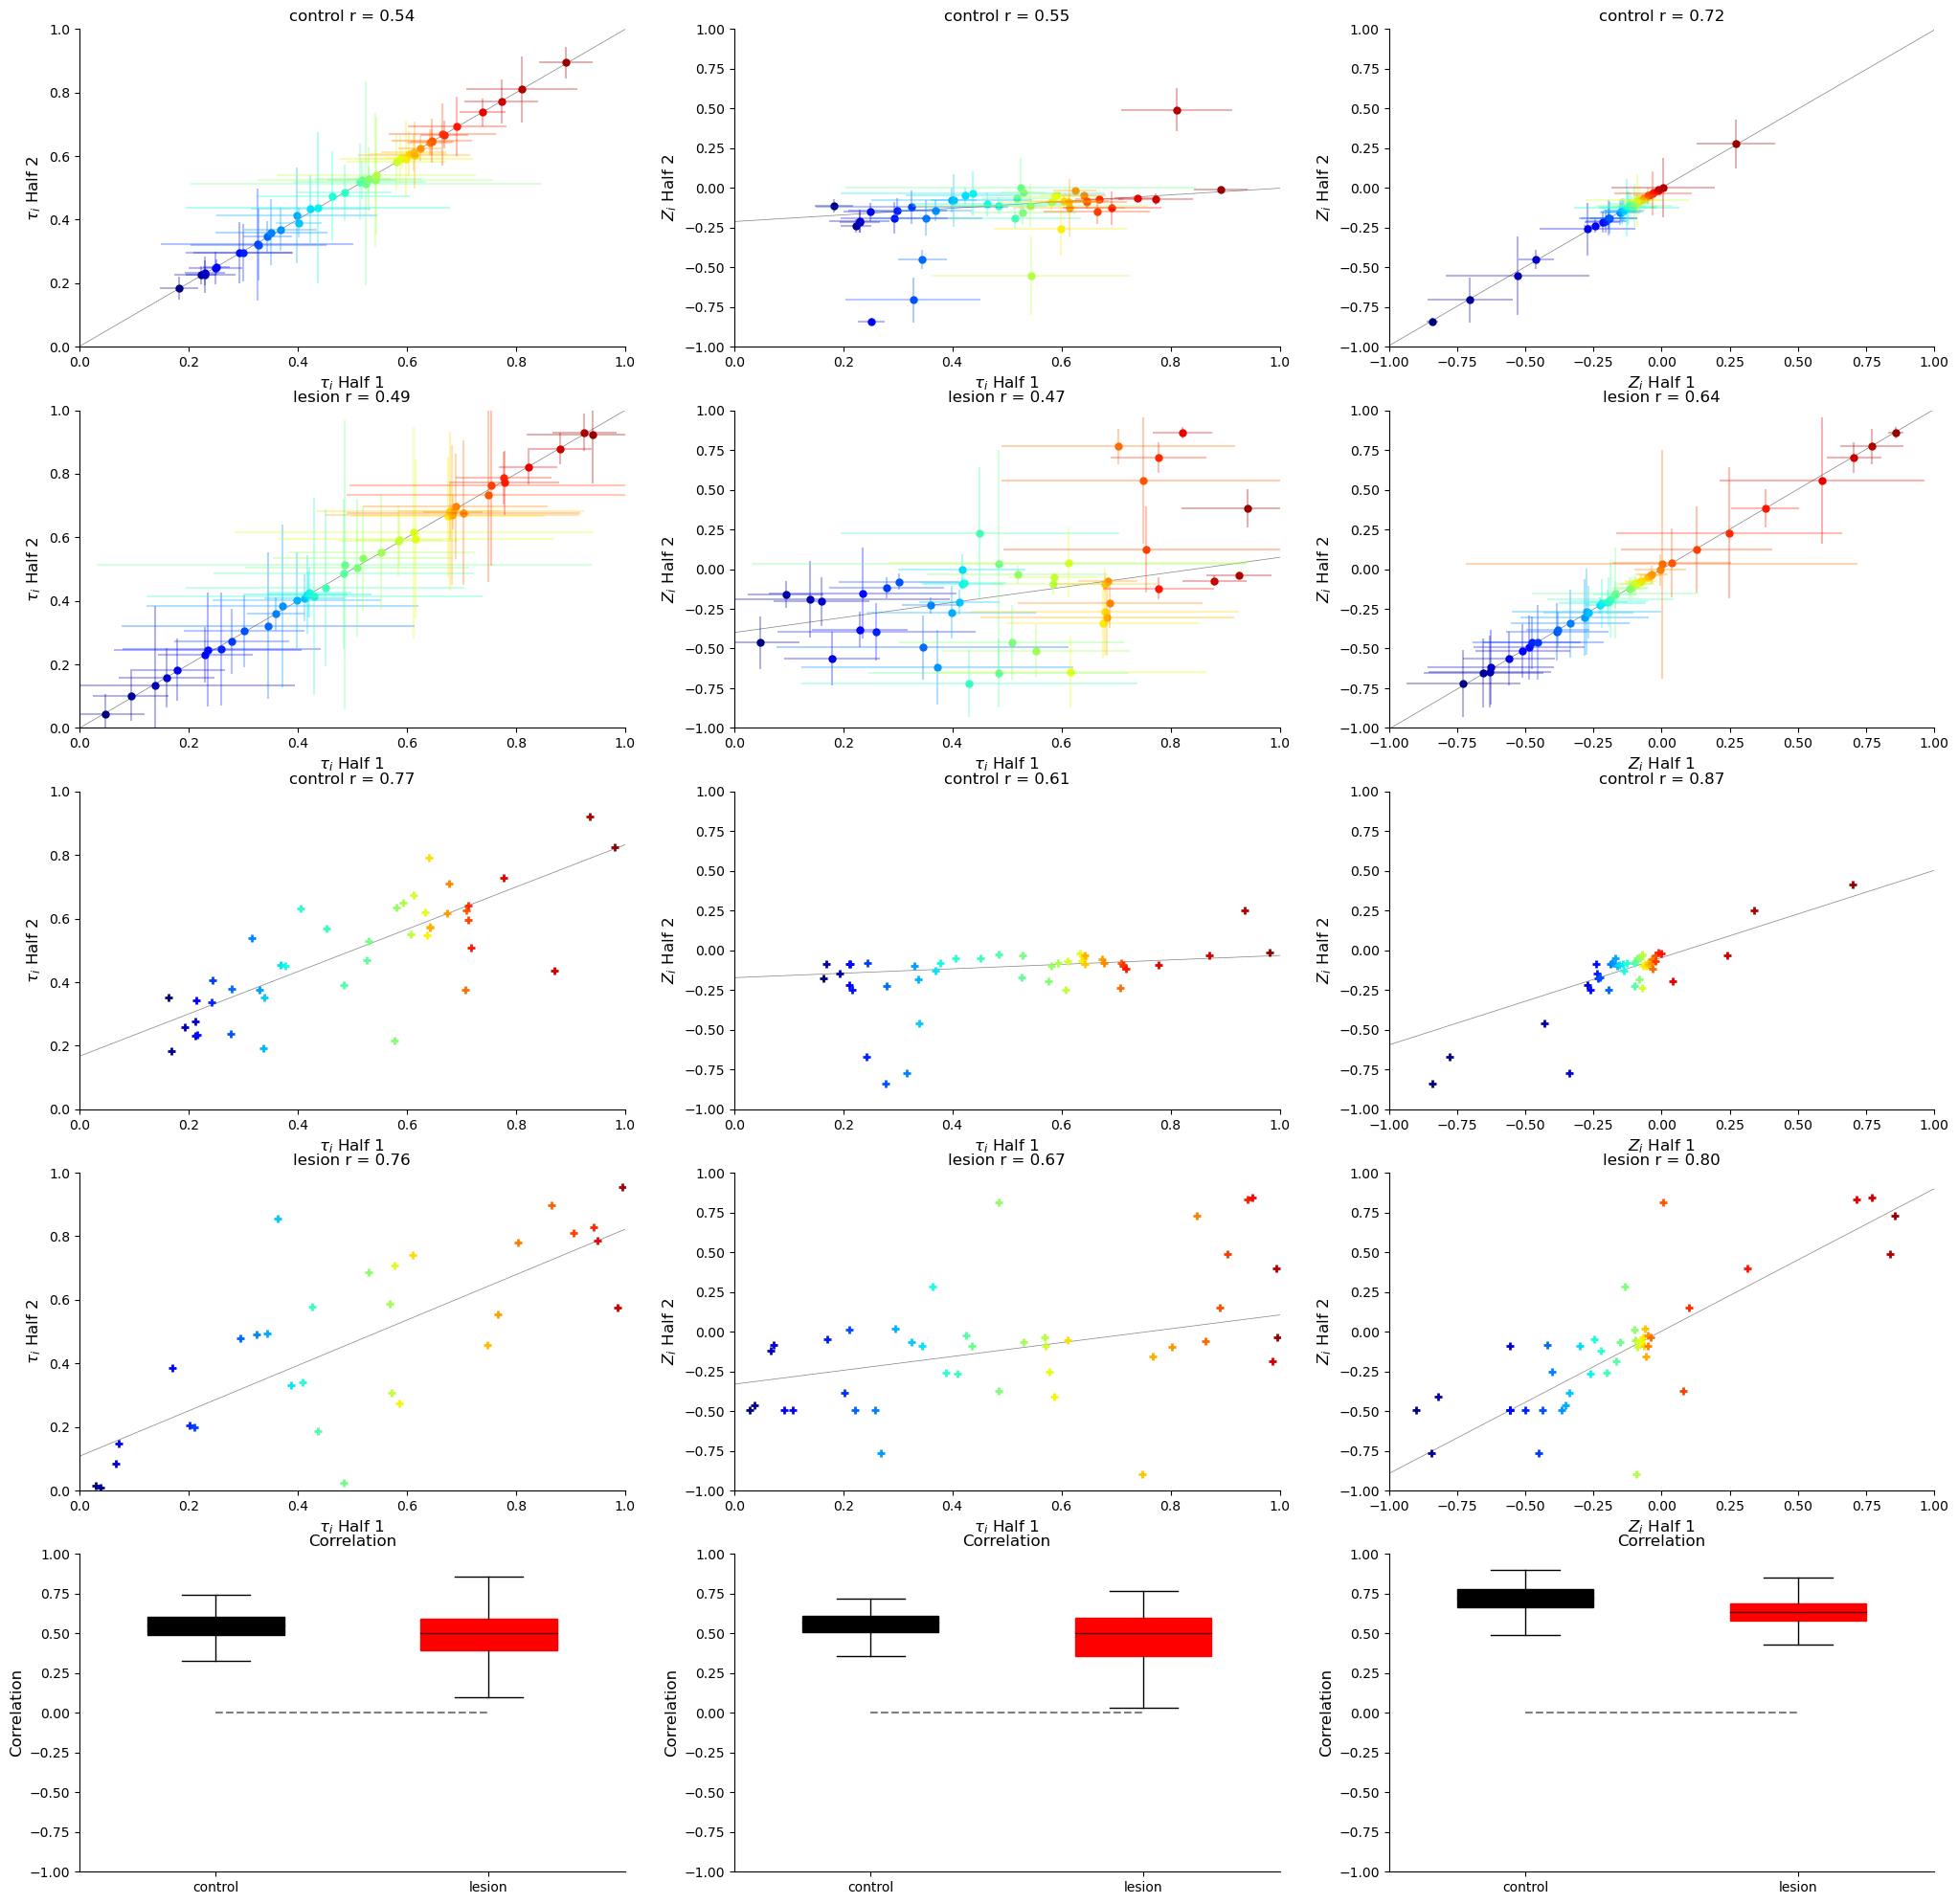

In [47]:
fig,ax = plt.subplots(5,3,figsize=(25,25))
fig_data = FigureWithData(fig)

xxs = [taus_half1_g,taus_half1_g,zcross_half1_g]
yys = [taus_half2_g,zcross_half2_g,zcross_half2_g]
comparisons = [
    ('Tau Half 1', 'Tau Half 2', taus_half1_g, taus_half2_g, correlation_taus_taus_g),
    ('Tau Half 1', 'Z Half 2', taus_half1_g, zcross_half2_g, correlation_zcross_taus_g),
    ('Z Half 1', 'Z Half 2', zcross_half1_g, zcross_half2_g, correlation_zcross_zcross_g)
]
xlims = [[0,1],[0,1],[-1,1]]
ylims = [[0,1],[-1,1],[-1,1]]
xnames = [r'$\tau_i$ Half 1',r'$\tau_i$ Half 1',r'$Z_i$ Half 1']
ynames = [r'$\tau_i$ Half 2',r'$Z_i$ Half 2',r'$Z_i$ Half 2']
correlations = [correlation_taus_taus_g,correlation_zcross_taus_g,correlation_zcross_zcross_g]
correlations_shuff = [correlation_taus_taus_shuff_g,correlation_zcross_taus_shuff_g,correlation_zcross_zcross_shuff_g]

for ig, group_name in enumerate(groups):

    for icorr, (x_label, y_label, x_data_group, y_data_group, corr_group) in enumerate(comparisons):

        xxi = np.array(xxs[icorr][ig])
        yyi = np.array(yys[icorr][ig])
        corrs_i = correlations[icorr] 
        mu_x=  np.nanmean(xxi,axis=0)
        sem_x= np.nanstd(xxi,axis=0)
        mu_y=  np.nanmean(yyi,axis=0)
        sem_y= np.nanstd(yyi,axis=0)

        id_sort = np.argsort(mu_x)
        mu_x = mu_x[id_sort]
        sem_x = sem_x[id_sort]
        mu_y = mu_y[id_sort]
        sem_y = sem_y[id_sort]
        # FIt linear model 
        res  =compute_slope(mu_x, mu_y)
        x_fit = np.linspace(xlims[icorr][0],xlims[icorr][1],100)
        y_fit = res[0]*x_fit + res[1]

        ax[ig,icorr].plot(x_fit, y_fit, color='grey', linewidth=.5)
        [ax[ig,icorr].plot(mu_x[ii],mu_y[ii],'o',color=cm.jet(ii/len(cells_id)),markersize=5) for ii in np.arange(len(cells_id))]
        ax[ig,icorr].set_xlim(xlims[icorr])
        ax[ig,icorr].set_ylim(ylims[icorr])
        [ax[ig,icorr].errorbar(mu_x[ii],mu_y[ii],xerr=sem_x[ii],yerr=sem_y[ii],alpha=.3,color=cm.jet(ii/len(cells_id))) for ii in np.arange(len(cells_id))]
        plot_config(ax[ig,icorr],xnames[icorr],ynames[icorr],12,False)
        ax[ig,icorr].set_title(groups[ig] + ' r = %.2f' % np.nanmean(correlations[icorr][ig]),fontsize=12)

        mean_corr = np.nanmean(np.concatenate([np.array(correlations[icorr][ig] )[:,None] for icorr in range(3)],axis=1),axis=1)
        id_plot = np.argmax(mean_corr)
        samp_x=  xxi[id_plot,:]
        samp_y=  yyi[id_plot,:]
        id_disc = np.isnan(samp_x)+np.isnan(samp_y)
        samp_x = np.delete(samp_x,id_disc)
        samp_y = np.delete(samp_y,id_disc)
        id_sort = np.argsort(samp_x)
        samp_x = samp_x[id_sort]
        samp_y = samp_y[id_sort]
        
        res  =compute_slope(samp_x, samp_y)
        x_fit = np.linspace(xlims[icorr][0],xlims[icorr][1],100)
        y_fit = res[0]*x_fit + res[1]
        ax[ig+2,icorr].plot(x_fit, y_fit, color='grey', linewidth=.5)
        [ax[ig+2,icorr].plot(samp_x[ii],samp_y[ii],'+',color=cm.jet(ii/len(samp_y)),markersize=6,markeredgewidth=2) for ii in np.arange(len(samp_y))]
        ax[ig+2,icorr].set_xlim(xlims[icorr])
        ax[ig+2,icorr].set_ylim(ylims[icorr])
        ax[ig+2,icorr].set_title(groups[ig] + ' r = %.2f' % np.nanmean(corrs_i[ig][id_plot]),fontsize=12)
        plot_config(ax[ig+2,icorr],xnames[icorr],ynames[icorr],12,False)

        # Stack data: x, y, x_err, y_err
        data_array = np.column_stack((mu_x, mu_y, sem_x, sem_y))
        headers = [f'{x_label}_mean', f'{y_label}_mean', f'{x_label}_SEM', f'{y_label}_SEM']
        section_name = f'{group_name}: {x_label} vs {y_label}'
        fig_data.add_data(section_name, data_array, headers)
        # Stack data: x, y, x_err, y_err
        data_array = np.column_stack((samp_x, samp_y))
        headers = [f'{x_label}_sample', f'{y_label}_sample']
        section_name = f'{group_name}: {x_label} vs {y_label}'
        fig_data.add_data(section_name, data_array, headers)
        # Add correlation stats
        corr_values = np.array(corr_group[ig])
        fig_data.add_stats(f'{section_name} Correlation', corr_values, ['r'])


for icorr in range(3):
    corrs_i = correlations[icorr] 
    corrs_i_shuff = correlations_shuff[icorr]
    boxplot_colors(ax[-1,icorr],corrs_i,['black','red'],[0,1],.5)
    ax[-1,icorr].plot([0,1],[0,0],
                     color='black',alpha=.5,linestyle='--')
    ax[-1,icorr].set_title('Correlation',fontsize=12)
    plot_config(ax[-1,icorr],'','Correlation',12,False)
    ax[-1,icorr].set_xticks([0,1])
    ax[-1,icorr].set_xticklabels(groups)
_=[ia.set_ylim([-1,1]) for ia in ax[-1,:]]

# Save the figure and data
fig_data.save(
    base_filename='figure_S4_scatter_correlation_analysis',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
    )